# BAAC dataset : EDA

# Contexte et objectif
## Contexte
Chaque année, la France enregistre environ 50 000 accidents corporels de la circulation routière.
L'Observatoire National Interministériel de la Sécurité Routière (ONISR) collecte et publie ces données via les _Bulletins d'Analyse des Accidents Corporels_ (BAAC). 

## Le jeu de données
Ce jeu de données contient __16 tables__. Il y a 4 tables par année reparties sur 4 ans: de 2021 à 2024. Chaque années contient une table __caractéristiques, une table lieux, une table vehicules et une dernière usagers__. \
La table carac (pour caractéristiques) décrit les circonstances générales de l’accident \
La table lieux décrit le lieu principal de l’accident\
La table usagers recense les usagers impliqués\
la table vehicules repertorie les véhicules impliqués

__nombre d'entrée pour chaque table__
|               | 2024  | 2023 | 2022 | 2021 | nombre de colonnes|
|---------------|-------|------|------|------|-------------------|
|__carac__      |54402  |54822 |55302 |56618 |15                 |
|__lieux__      |70248  |70860 |55302 |56518 |18                 |
|__usagers__    |125187 |125789|129248|129248|18                 |
|__vehicules__  |92678  |93585 |97315 | 97315|11                 |

## Problématique
Peut-on prédire la gravité d'un accident à partir des caractéristiques de l'accident, de l'environnement, de l'infrastructure et des usagers ?

# Import et chargement des données

In [3]:
#Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [4]:
# Chargement des données

carac_2024 = pd.read_csv("../data/raw/caract-2024.csv", sep=";")
usagers_2024 = pd.read_csv("../data/raw/usagers-2024.csv", sep=";")
lieux_2024 = pd.read_csv("../data/raw/lieux-2024.csv", sep=";")
vehicules_2024 = pd.read_csv("../data/raw/vehicules-2024.csv", sep=";")

carac_2023 = pd.read_csv("../data/raw/caract-2023.csv", sep=";")
usagers_2023 = pd.read_csv("../data/raw/usagers-2023.csv", sep=";")
lieux_2023 = pd.read_csv("../data/raw/lieux-2023.csv", sep=";", low_memory=False)
vehicules_2023 = pd.read_csv("../data/raw/vehicules-2023.csv", sep=";")

carac_2022 = pd.read_csv("../data/raw/carcteristiques-2022.csv", sep=";")
usagers_2022 = pd.read_csv("../data/raw/usagers-2022.csv", sep=";")
lieux_2022 = pd.read_csv("../data/raw/lieux-2022.csv", sep=";", low_memory=False)
vehicules_2022 = pd.read_csv("../data/raw/vehicules-2022.csv", sep=";")

carac_2021 = pd.read_csv("../data/raw/carcteristiques-2021.csv", sep=";")
usagers_2021 = pd.read_csv("../data/raw/usagers-2021.csv", sep=";")
lieux_2021 = pd.read_csv("../data/raw/lieux-2021.csv", sep=";", low_memory=False)
vehicules_2021 = pd.read_csv("../data/raw/vehicules-2021.csv", sep=";")

# Compréhension du schéma
Concatener permets de faciliter la manipulation des données. Mais avant il faut vérifier la structure des tables
## Structure des tables

In [5]:
#verifier le nom des colonnes
#carac
verif = { 
        'c2024' : carac_2024,
        'c2023' : carac_2023,
        'c2022' : carac_2022,
        'c2021' : carac_2021,
}

for x in verif:
    y = verif[x]

    nom = y.columns
    print(f'{x}:', nom)

c2024: Index(['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg',
       'int', 'atm', 'col', 'adr', 'lat', 'long'],
      dtype='str')
c2023: Index(['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg',
       'int', 'atm', 'col', 'adr', 'lat', 'long'],
      dtype='str')
c2022: Index(['Accident_Id', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg',
       'int', 'atm', 'col', 'adr', 'lat', 'long'],
      dtype='str')
c2021: Index(['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg',
       'int', 'atm', 'col', 'adr', 'lat', 'long'],
      dtype='str')


In [6]:
#usagers
verif = { 
        'u2024' : usagers_2024,
        'u2023' : usagers_2023,
        'u2022' : usagers_2022,
        'u2021' : usagers_2021,
}

for x in verif:
    y = verif[x]

    nom = y.columns
    print(f'{x}:', nom)

u2024: Index(['Num_Acc', 'id_usager', 'id_vehicule', 'num_veh', 'place', 'catu',
       'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2', 'secu3', 'locp',
       'actp', 'etatp'],
      dtype='str')
u2023: Index(['Num_Acc', 'id_usager', 'id_vehicule', 'num_veh', 'place', 'catu',
       'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2', 'secu3', 'locp',
       'actp', 'etatp'],
      dtype='str')
u2022: Index(['Num_Acc', 'id_usager', 'id_vehicule', 'num_veh', 'place', 'catu',
       'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2', 'secu3', 'locp',
       'actp', 'etatp'],
      dtype='str')
u2021: Index(['Num_Acc', 'id_usager', 'id_vehicule', 'num_veh', 'place', 'catu',
       'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2', 'secu3', 'locp',
       'actp', 'etatp'],
      dtype='str')


In [7]:
#lieux
verif = { 
        'l2024' : lieux_2024,
        'l2023' : lieux_2023,
        'l2022' : lieux_2022,
        'l2021' : lieux_2021,
}

for x in verif:
    y = verif[x]

    nom = y.columns
    print(f'{x}:', nom)

l2024: Index(['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'vosp', 'prof',
       'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ',
       'vma'],
      dtype='str')
l2023: Index(['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'vosp', 'prof',
       'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ',
       'vma'],
      dtype='str')
l2022: Index(['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'vosp', 'prof',
       'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ',
       'vma'],
      dtype='str')
l2021: Index(['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'vosp', 'prof',
       'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ',
       'vma'],
      dtype='str')


In [8]:
#vehicules
verif = { 
        'v2024' : vehicules_2024,
        'v2023' : vehicules_2023,
        'v2022' : vehicules_2022,
        'v2021' : vehicules_2021,
}

for x in verif:
    y = verif[x]

    nom = y.columns
    print(f'{x}:', nom)

v2024: Index(['Num_Acc', 'id_vehicule', 'num_veh', 'senc', 'catv', 'obs', 'obsm',
       'choc', 'manv', 'motor', 'occutc'],
      dtype='str')
v2023: Index(['Num_Acc', 'id_vehicule', 'num_veh', 'senc', 'catv', 'obs', 'obsm',
       'choc', 'manv', 'motor', 'occutc'],
      dtype='str')
v2022: Index(['Num_Acc', 'id_vehicule', 'num_veh', 'senc', 'catv', 'obs', 'obsm',
       'choc', 'manv', 'motor', 'occutc'],
      dtype='str')
v2021: Index(['Num_Acc', 'id_vehicule', 'num_veh', 'senc', 'catv', 'obs', 'obsm',
       'choc', 'manv', 'motor', 'occutc'],
      dtype='str')


# Harmonisation des données
## Noms des colonnes

In [9]:
#remplacer 'Accident_Id' de caract_2022 par 'Num_Acc'
carac_2022 = carac_2022.rename(columns={'Accident_Id':'Num_Acc'})

## Concaténation des années

In [10]:
# Concaténation des tables 
carac = pd.concat([carac_2024, carac_2023, carac_2022, carac_2021], ignore_index=True)
usagers = pd.concat([usagers_2024, usagers_2023, usagers_2022, usagers_2021], ignore_index=True)
lieux = pd.concat([lieux_2024, lieux_2023, lieux_2022, lieux_2021], ignore_index=True)
vehicules = pd.concat([vehicules_2024, vehicules_2023, vehicules_2022, vehicules_2021], ignore_index=True)

# Qualité de la donnée
## Granularité

In [11]:
data = { 
    'carac' : carac,
    'usagers' : usagers,
    'lieux' : lieux,
    'vehicules' : vehicules
}

In [12]:
for x in data:
    y = data[x]
    print(f'{x}:', len(y), y['Num_Acc'].nunique())
    print(f'{x}:', y['Num_Acc'].value_counts().value_counts())

carac: 221044 221044
carac: count
1    221044
Name: count, dtype: int64
usagers: 506886 221044
usagers: count
2     127947
1      36585
3      33610
4      12294
5       5665
6       2572
7       1124
8        531
9        297
10       142
11        76
12        50
13        42
14        23
15        12
18        10
21         7
17         7
16         7
20         6
36         3
22         3
19         3
39         2
31         2
30         2
29         2
28         2
26         2
65         1
56         1
54         1
51         1
50         1
49         1
48         1
47         1
43         1
41         1
38         1
35         1
27         1
25         1
24         1
23         1
Name: count, dtype: int64
lieux: 252928 221044
lieux: count
1    189529
2     31178
3       307
4        28
5         2
Name: count, dtype: int64
vehicules: 378071 221044
vehicules: count
2     122208
1      83687
3      11954
4       2342
5        609
6        143
7         54
8         22
9         10


La table carac est à la granularité de l'accident : chaque Num_Acc correspond à une seule ligne. Les tables usagers, lieux et vehicules présentent une granularité différente : plusieurs lignes peuvent être associées à un même Num_Acc. Il existe donc une relation 1:N entre un accident et les usagers, les véhicules et certaines informations de lieu associées.

| Table       | Une ligne correspond à…                   | Conséquence                                 |
| ----------- | ----------------------------------------- | ------------------------------------------- |
| `carac`     | **un accident**                           | `Num_Acc` est normalement unique            |
| `lieux`     | **un lieu associé à un accident**         | un `Num_Acc` peut apparaître plusieurs fois |
| `usagers`   | **un usager impliqué dans un accident**   | un `Num_Acc` peut apparaître plusieurs fois |
| `vehicules` | **un véhicule impliqué dans un accident** | un `Num_Acc` peut apparaître plusieurs fois |

## Valeurs inexploitables
La doc nous apprends que les valeurs -1 sont à considérer comme nulles, donc inexploitables

In [13]:
nan = {}
neg = {}
nul = {}
for x in data:
    y = data[x]
    nan[x] = y.isna().sum()
    neg[x] = (y == -1).sum()
    nul[x] = nan[x] + neg[x]

    print(f'NAN de {x}:', nan[x].sum())
    print(f'NEG de {x}:', neg[x].sum())
    print(f'VALEURS INEXPLOITABLES DE {x}:', nul[x].sum())
    print('~'*50)

NAN de carac: 5505
NEG de carac: 132
VALEURS INEXPLOITABLES DE carac: 5637
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
NAN de usagers: 11118
NEG de usagers: 1454373
VALEURS INEXPLOITABLES DE usagers: 1465491
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
NAN de lieux: 518901
NEG de lieux: 90997
VALEURS INEXPLOITABLES DE lieux: 609898
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
NAN de vehicules: 374723
NEG de vehicules: 2259
VALEURS INEXPLOITABLES DE vehicules: 376982
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


### Valeurs Inexploitables: Usagers

In [14]:
(usagers == -1).sum()

Num_Acc             0
id_usager           0
id_vehicule         0
num_veh             0
place              30
catu                0
grav              419
sexe            10632
an_nais             0
trajet          11269
secu1            9865
secu2          223921
secu3          489711
locp           240813
actp                0
etatp          467713
dtype: int64

In [15]:
usagers.isna().sum()

Num_Acc            0
id_usager          0
id_vehicule        0
num_veh            0
place              0
catu               0
grav               0
sexe               0
an_nais        11118
trajet             0
secu1              0
secu2              0
secu3              0
locp               0
actp               0
etatp              0
dtype: int64

### Valeurs inexploitables : Lieux

In [16]:
print('nan:', lieux.isna().sum())
print('-'*50)
print('neg:', (lieux==-1).sum())

nan: Num_Acc         0
catr            0
voie        35290
v1              0
v2         230883
circ            0
nbv             0
vosp            0
prof            0
pr              0
pr1             0
plan            0
lartpc     252728
larrout         0
surf            0
infra           0
situ            0
vma             0
dtype: int64
--------------------------------------------------
neg: Num_Acc        0
catr           0
voie           0
v1         52457
v2             0
circ       15773
nbv          559
vosp        8160
prof         280
pr             0
pr1            0
plan         220
lartpc         0
larrout        0
surf         269
infra       3048
situ         251
vma         9980
dtype: int64


### Valeurs inexploitables: Vehicules

In [17]:
print('nan:', vehicules.isna().sum())
print('-'*50)
print('neg:', (vehicules==-1).sum())

nan: Num_Acc             0
id_vehicule         0
num_veh             0
senc                0
catv                0
obs                 0
obsm                0
choc                0
manv                0
motor               0
occutc         374723
dtype: int64
--------------------------------------------------
neg: Num_Acc          0
id_vehicule      0
num_veh          0
senc           865
catv            12
obs            176
obsm           162
choc           211
manv           122
motor          711
occutc           0
dtype: int64


### Valeurs inexploitables: Carac

In [18]:
print('nan:', carac.isna().sum())
print('-'*50)
print('neg:', (carac==-1).sum())

nan: Num_Acc       0
jour          0
mois          0
an            0
hrmn          0
lum           0
dep           0
com           0
agg           0
int           0
atm           0
col           0
adr        5505
lat           0
long          0
dtype: int64
--------------------------------------------------
neg: Num_Acc      0
jour         0
mois         0
an           0
hrmn         0
lum          4
dep          0
com          0
agg          0
int         13
atm         13
col        102
adr          0
lat          0
long         0
dtype: int64


### Observations

| Tables        |     NaN |      `-1` | Valeurs inexploitables | % non exploitables |
| ------------- | ------: | --------: | ---------------------: | -----------------: |
| **carac**     |   5 505 |       132 |                  5 637 |         **1,70 %** |
| **usagers**   |  11 118 | 1 454 373 |              1 465 491 |        **16,04 %** |
| **lieux**     | 518 901 |    90 997 |                609 898 |        **13,40 %** |
| **vehicules** | 374 723 |     2 259 |                376 982 |         **9,01 %** |


L’analyse des valeurs manquantes montre que leur impact varie selon les variables. Certaines valeurs manquantes peuvent s’expliquer par la nature même de la variable, notamment pour `v2`, `lartpc` ou `occutc`, et ne constituent donc pas nécessairement une anomalie.

Une attention particulière est portée aux variables susceptibles d’être utilisées pour l’analyse et la modélisation, notamment `grav`, `vma`, `sexe`, `an_nais`, `catv`, `atm` et `lum`. Les valeurs manquantes de `grav` sont particulièrement importantes puisqu’il s’agit de la variable cible.

Le traitement de ces valeurs sera déterminé lors de l’étape de prétraitement.

## Doublons

In [19]:
carac[carac.duplicated()]

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long


In [20]:
usagers[usagers.duplicated()]

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp


In [21]:
lieux[lieux.duplicated()]

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
15885,202400012279,3,NaN,-1,NaN,2,-1,-1,2,-1,-1,1,NaN,-1,1,0,1,-1
57343,202400044389,4,NaN,-1,NaN,2,-1,-1,1,-1,-1,1,NaN,-1,1,0,1,-1


In [22]:
vehicules[vehicules.duplicated()]

,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc


Deux doublons sont identifiés dans la table lieux, soit une proportion négligeable au regard du volume total de données. Aucun doublon exact n'est observé dans les autres tables.

## Cohérence des données
### Variables temporelles 
__jour__ -> doit être entre 1 et 31\
__mois__ -> entre 1 et 12\
__an__ -> 2021 à 2024 dans ton périmètre\
__an_nais__ -> verifier la cohérence

In [23]:
carac['an'].value_counts()

an
2021    56518
2022    55302
2023    54822
2024    54402
Name: count, dtype: int64

In [24]:
carac['jour'].value_counts().sort_index()

jour
1     6988
2     7110
3     7238
4     7284
5     7340
6     7470
7     7540
8     7587
9     7579
10    7449
11    7357
12    7448
13    7508
14    7421
15    7249
16    7424
17    7218
18    7232
19    7313
20    7172
21    7304
22    7187
23    7172
24    7064
25    6976
26    7032
27    7177
28    7157
29    6642
30    6513
31    3893
Name: count, dtype: int64

In [25]:
carac['mois'].value_counts().sort_index()

mois
1     15860
2     14725
3     17002
4     16929
5     19418
6     21870
7     20404
8     17334
9     20371
10    21050
11    18517
12    17564
Name: count, dtype: int64

In [26]:
usagers['an_nais'].min()

np.float64(1912.0)

In [27]:
usagers['an_nais'].max()

np.float64(2024.0)

In [28]:
usagers["an_nais"].value_counts().sort_index()

an_nais
1912.0       1
1913.0       5
1914.0       1
1915.0       2
1917.0       1
          ... 
2020.0    1329
2021.0    1213
2022.0     866
2023.0     480
2024.0     175
Name: count, Length: 111, dtype: int64

## Variables catégorielles
variables candidates pour le modèle:
grav : -1, 1->4
sexe : -1, 1, 2 
lum : 1->5
atm : -1, 1->9
catv : -1, 00->43, 50, 60, 80, 99
catu : 1, 2, 3
surf : -1, 1->9

In [29]:
lieux['surf'].value_counts()

surf
 1    202430
 2     46679
 9      1227
 7       892
 3       402
 5       383
 8       327
-1       269
 6       205
 4       114
Name: count, dtype: int64

In [30]:
usagers['grav'].value_counts()

grav
 1    215092
 4    201026
 3     76750
 2     13599
-1       419
Name: count, dtype: int64

In [31]:
print(usagers['sexe'].value_counts(), usagers['catu'].value_counts())

sexe
 1    338907
 2    157347
-1     10632
Name: count, dtype: int64 catu
1    377740
2     91141
3     38005
Name: count, dtype: int64


In [32]:
print(carac['atm'].value_counts(), carac['lum'].value_counts())

atm
 1    174852
 2     24380
 8      8781
 3      5084
 7      3904
 5      1698
 9      1014
 4       723
 6       595
-1        13
Name: count, dtype: int64 lum
 1    147819
 5     33754
 3     22622
 2     14610
 4      2235
-1         4
Name: count, dtype: int64


In [33]:
vehicules['catv'].value_counts().sort_index()

catv
-1         12
 0       1038
 1      21099
 2      13522
 3       1984
 7     221038
 10     27419
 13      1524
 14      2825
 15      3764
 16       134
 17      2304
 20       261
 21      1023
 30     10356
 31      6656
 32      7859
 33     30324
 34      3528
 35        86
 36       697
 37      2641
 38       707
 39       140
 40       492
 41        68
 42        75
 43      2401
 50      8859
 60       943
 80      2757
 99      1535
Name: count, dtype: int64

## Variables Numériques
vma

In [34]:
lieux['vma'].value_counts().sort_values()

vma
 85          1
 95          1
 502         1
 501         1
 9           1
 901         1
 180         1
 520         1
 8           1
 23          1
 65          1
 31          1
 301         1
 16          1
 0           1
 800         1
 12          1
 770         1
 55          2
 140         2
 4           3
 700         4
 75          5
 900         6
 35          7
 300         8
 3          11
 6          18
 2          25
 500        36
 100        41
 1          55
 45         73
 5          99
 15        134
 25        192
 40        272
 10        433
 60        449
 20        848
 130      4209
 110      7731
-1        9980
 70      16513
 90      18890
 80      31848
 30      42067
 50     118949
Name: count, dtype: int64

Les observations ne mettent pas en évidence d’incohérences manifestes, à l’exception de __vma__, dont plusieurs valeurs nécessitent une vérification au regard du codage BAAC. Les valeurs -1 sont considérées séparément comme des valeurs codées non renseignées.

## Valeurs abérrantes
### an_nais
Les valeurs extrêmes observées pour an_nais restent cohérentes avec la population étudiée. Elles correspondent notamment à des usagers très jeunes ou très âgés, dont la présence dans les accidents est possible. Aucun traitement spécifique n'est donc nécessaire pour cette variable à ce stade.
### vma

In [35]:
lieux['vma'].describe()

count    252928.000000
mean         55.784243
std          26.177332
min          -1.000000
25%          50.000000
50%          50.000000
75%          70.000000
max         901.000000
Name: vma, dtype: float64

In [36]:
lieux["vma"].value_counts().sort_index(ascending=False)

vma
 901         1
 900         6
 800         1
 770         1
 700         4
 520         1
 502         1
 501         1
 500        36
 301         1
 300         8
 180         1
 140         2
 130      4209
 110      7731
 100        41
 95          1
 90      18890
 85          1
 80      31848
 75          5
 70      16513
 65          1
 60        449
 55          2
 50     118949
 45         73
 40        272
 35          7
 31          1
 30      42067
 25        192
 23          1
 20        848
 16          1
 15        134
 12          1
 10        433
 9           1
 8           1
 6          18
 5          99
 4           3
 3          11
 2          25
 1          55
 0           1
-1        9980
Name: count, dtype: int64

Les valeurs observées sont comparées aux limitations de vitesse réglementaires applicables sur le réseau routier français. Certaines valeurs, telles que 300 km/h ou 9 km/h, apparaissent incompatibles avec les vitesses maximales autorisées prévues par la réglementation et sont donc considérées comme incohérentes et aberrantes.

## Types

In [37]:
carac.dtypes

Num_Acc    int64
jour       int64
mois       int64
an         int64
hrmn         str
lum        int64
dep          str
com          str
agg        int64
int        int64
atm        int64
col        int64
adr          str
lat          str
long         str
dtype: object

In [38]:
usagers.dtypes

Num_Acc          int64
id_usager          str
id_vehicule        str
num_veh            str
place            int64
catu             int64
grav             int64
sexe             int64
an_nais        float64
trajet           int64
secu1            int64
secu2            int64
secu3            int64
locp             int64
actp               str
etatp            int64
dtype: object

In [39]:
lieux.dtypes

Num_Acc     int64
catr        int64
voie          str
v1          int64
v2            str
circ        int64
nbv        object
vosp        int64
prof        int64
pr            str
pr1           str
plan        int64
lartpc        str
larrout       str
surf        int64
infra       int64
situ        int64
vma         int64
dtype: object

In [40]:
vehicules.dtypes

Num_Acc          int64
id_vehicule        str
num_veh            str
senc             int64
catv             int64
obs              int64
obsm             int64
choc             int64
manv             int64
motor            int64
occutc         float64
dtype: object

In [41]:
for nom, df in data.items():
    print(nom)
    print(df.dtypes)
    print()

carac
Num_Acc    int64
jour       int64
mois       int64
an         int64
hrmn         str
lum        int64
dep          str
com          str
agg        int64
int        int64
atm        int64
col        int64
adr          str
lat          str
long         str
dtype: object

usagers
Num_Acc          int64
id_usager          str
id_vehicule        str
num_veh            str
place            int64
catu             int64
grav             int64
sexe             int64
an_nais        float64
trajet           int64
secu1            int64
secu2            int64
secu3            int64
locp             int64
actp               str
etatp            int64
dtype: object

lieux
Num_Acc     int64
catr        int64
voie          str
v1          int64
v2            str
circ        int64
nbv        object
vosp        int64
prof        int64
pr            str
pr1           str
plan        int64
lartpc        str
larrout       str
surf        int64
infra       int64
situ        int64
vma         int64
dty

### Observations
La majorité des variables présentent des types cohérents avec leur nature. Quelques variables présentent toutefois des types nécessitant une attention particulière, notamment an_nais, nbv, lat et long.
### Qualité des données - conclusion
Le jeu de données est globalement exploitable. Quelques valeurs manquantes, valeurs codées -1, doublons et valeurs atypiques ont été identifiés, notamment pour vma. Ces éléments seront pris en compte lors du prétraitement.

# Construction du dataset d’analyse

L’objectif est de construire un dataset dont une ligne correspond à un usager impliqué dans un accident, afin de conserver grav comme variable cible au niveau individuel.

Avant de sélectionner les variables, plusieurs dimensions d'information sont retenues comme potentiellement pertinentes pour expliquer la gravité d'un accident :

* __Contexte environnemental__ : conditions météorologiques, luminosité, état de la chaussée, etc.
* __Infrastructure et contexte routier__ : type de route, nombre de voies, vitesse maximale autorisée, etc.
* __Véhicule__ : catégorie du véhicule, caractéristiques et éléments de sécurité, etc.
* __Usager__ : âge, sexe, catégorie d'usager, équipements de sécurité, etc.
* __Contexte temporel__ : heure, jour, mois et année de l'accident.


__Variables retenues__
| Dimension                  | Variables                                                                               |
| ---------------------------| --------------------------------------------------------------------------------------- |
| Environnement              | `atm`, `lum`, `surf`                                                                    |
| Infrastructure / route     | `catr`, `nbv`, `vosp`, `prof`, `plan`, `infra`, `situ`, `vma`                   |
| Véhicule                   | `catv`, `motor`, `choc`, `manv`, `obs`, `obsm`                                          |
| Usager                     | `an_nais`, `sexe`, `catu`, `secu1`, `secu2`, `secu3`, `locp`, `actp`, `etatp` |
| Temps                      | `jour`, `mois`, `an`, `hrmn`                                                            |
| __Cible__                  | `grav`                                                                                  |
| _Clé techniques_           | `Num_Acc`, `id_vehicules`, `num_veh`, `id_usager`                                       |

## Selection des variables pertinentes

In [42]:
carac_ana = carac[['Num_Acc','an','lum', 'agg', 'atm']]
usagers_ana = usagers[['Num_Acc','id_usager','id_vehicule','num_veh','grav','catu','sexe','an_nais','secu1','secu2','secu3']]
lieux_ana = lieux[['Num_Acc','nbv','surf','vma']]
vehicules_ana = vehicules[['Num_Acc','id_vehicule','catv','motor']]

## Vérification des clé avant merge

In [43]:
print('carac:',carac_ana['Num_Acc'].is_unique,
      'usagers:',usagers_ana['id_usager'].is_unique,
      'vehicules:',vehicules_ana['id_vehicule'].is_unique)

carac: True usagers: True vehicules: True


In [44]:
lieux['Num_Acc'].value_counts().value_counts().sort_index

<bound method Series.sort_index of count
1    189529
2     31178
3       307
4        28
5         2
Name: count, dtype: int64>

### Lieux
__hypthèse__ : Les doublons de 'Num_Acc' viennent du fait que les accidents ont eu lieu dans des zones d'intersections (carrefour, giratoire, intersection)

In [45]:
inter = carac[['Num_Acc', 'int']]
dup = lieux[lieux['Num_Acc'].duplicated(keep=False)]
inter = inter.merge(dup, on='Num_Acc', how='left')

In [46]:
inter

,Num_Acc,int,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,202400000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,202400000002,3,4.0,HOTEL DIEU (RUE DE L'),0.0,NaN,2.0,2,0.0,1.0,-1,-1,1.0,NaN,-1,9.0,0.0,1.0,30.0
2,202400000002,3,4.0,POTERNE (RUE),0.0,NaN,1.0,1,0.0,1.0,-1,-1,1.0,NaN,-1,9.0,0.0,1.0,30.0
3,202400000003,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,202400000004,3,4.0,AUTHIE (N° 106 PAIRS -115 IMPAIRS),0.0,NaN,2.0,4,0.0,1.0,-1,-1,1.0,NaN,-1,1.0,9.0,1.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252923,202100056514,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252924,202100056515,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252925,202100056516,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252926,202100056517,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
inter['int'].value_counts()

int
 1    140899
 2     39734
 3     37663
 6     12535
 9     10218
 4      6882
 7      2567
 5      1819
 8       597
-1        14
Name: count, dtype: int64

In [48]:
inter[['Num_Acc', 'int']].drop_duplicates()['int'].value_counts()

int
 1    140899
 2     26852
 3     25081
 6      9872
 9      9699
 4      4748
 7      2120
 5      1243
 8       517
-1        13
Name: count, dtype: int64

Parmis les accidents ayant plusieurs lignes dans lieux, la majorité ont int = 1 (hors intersection), on ne peut donc pas expliquer la multiplicité uniquement par les carrefours/giratoires.

In [49]:
lieux_ana['Num_Acc'].value_counts().value_counts().sort_index()

count
1    189529
2     31178
3       307
4        28
5         2
Name: count, dtype: int64

In [50]:
lieux_ana[lieux_ana['Num_Acc'] == 202300054805]

,Num_Acc,nbv,surf,vma
141088,202300054805,2,1,90
141089,202300054805,4,1,90


In [51]:
lieux_ana[lieux_ana['Num_Acc'] == 202400000005]

,Num_Acc,nbv,surf,vma
6,202400000005,4,2,50
7,202400000005,4,2,70


In [52]:
lieux_ana[lieux_ana['Num_Acc'] == 202300054799]

,Num_Acc,nbv,surf,vma
141081,202300054799,2,1,-1
141082,202300054799,2,1,50


### Observation et conclusion : Lieux
Un même accident peut être associé à plusieurs enregistrements dans lieux, notamment lorsque plusieurs éléments de voirie sont concernés.

Afin d'obtenir une ligne par accident, les données de `lieux_ana` sont agrégées par `Num_Acc`. `circ` et `surf` sont conservées via la première valeur observée, tandis que `vma` est représentée par sa valeur maximale. Ce choix constitue une simplification nécessaire pour la fusion et pourra être réévalué lors de l'analyse.


In [53]:
lieux_agg = lieux_ana.groupby('Num_Acc').agg({
    'surf': 'first',
    'vma': 'max'
}).reset_index()
lieux_agg

,Num_Acc,surf,vma
0,202100000001,1,80
1,202100000002,1,80
2,202100000003,1,50
3,202100000004,1,50
4,202100000005,1,50
...,...,...,...
221039,202400054398,2,50
221040,202400054399,1,30
221041,202400054400,1,110
221042,202400054401,1,50


## Jointure des tables

In [54]:
df = usagers_ana.merge(carac_ana,on='Num_Acc',how='left')

In [55]:
len(df) == len(usagers_ana)

True

In [56]:
df = df.merge(lieux_agg,on='Num_Acc',how='left')
df = df.merge(vehicules_ana,on='id_vehicule',how='left')

In [57]:
len(df) == len(usagers_ana)

True

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506886 entries, 0 to 506885
Data columns (total 20 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc_x    506886 non-null  int64  
 1   id_usager    506886 non-null  str    
 2   id_vehicule  506886 non-null  str    
 3   num_veh      506886 non-null  str    
 4   grav         506886 non-null  int64  
 5   catu         506886 non-null  int64  
 6   sexe         506886 non-null  int64  
 7   an_nais      495768 non-null  float64
 8   secu1        506886 non-null  int64  
 9   secu2        506886 non-null  int64  
 10  secu3        506886 non-null  int64  
 11  an           506886 non-null  int64  
 12  lum          506886 non-null  int64  
 13  agg          506886 non-null  int64  
 14  atm          506886 non-null  int64  
 15  surf         506886 non-null  int64  
 16  vma          506886 non-null  int64  
 17  Num_Acc_y    506886 non-null  int64  
 18  catv         506886 non-null  int64

# Nettoyage et traitement préalable à l'EDA
## Valeurs Inexploitables
### Valeurs inexploitables de la variabe cible

In [59]:
df = df[df['grav'] != -1]
df = df.dropna(subset=['grav'])

In [60]:
df['grav'].isna().sum()

np.int64(0)

In [61]:
df[df['grav']==-1]

,Num_Acc_x,id_usager,id_vehicule,num_veh,grav,catu,sexe,an_nais,secu1,secu2,secu3,an,lum,agg,atm,surf,vma,Num_Acc_y,catv,motor


In [62]:
df.isna().sum()

Num_Acc_x          0
id_usager          0
id_vehicule        0
num_veh            0
grav               0
catu               0
sexe               0
an_nais        10700
secu1              0
secu2              0
secu3              0
an                 0
lum                0
agg                0
atm                0
surf               0
vma                0
Num_Acc_y          0
catv               0
motor              0
dtype: int64

In [63]:
(df==-1).sum()

Num_Acc_x           0
id_usager           0
id_vehicule         0
num_veh             0
grav                0
catu                0
sexe            10216
an_nais             0
secu1            9486
secu2          223508
secu3          489298
an                  0
lum                 6
agg                 0
atm                23
surf              157
vma              7415
Num_Acc_y           0
catv               16
motor             843
dtype: int64

## Traitement des valeurs de secu1,2,3
Les variables `secu1`, `secu2` et `secu3` seront étudiées conjointement afin d’évaluer la pertinence de leur regroupement en une variable binaire `issecu`, en tenant compte de leur dépendance au type d’usager ou de véhicule.

In [64]:
df[['secu1', 'secu2', 'secu3']].notna().any(axis=1).value_counts(normalize=True) * 100

True    100.0
Name: proportion, dtype: float64

In [65]:
secu = df[['catu', 'secu1', 'secu2', 'secu3']]

secu = secu.replace(-1, np.nan)

In [66]:
secu[['secu1', 'secu2', 'secu3']].notna().any(axis=1).value_counts(normalize=True) * 100

True     98.21785
False     1.78215
Name: proportion, dtype: float64

In [67]:
df = df[df[['secu1', 'secu2', 'secu3']].replace(-1, np.nan).notna().any(axis=1)]

In [68]:
for col in ['secu1', 'secu2', 'secu3']:
    print(col)
    print(df[col].value_counts(dropna=False).sort_index())

secu1
secu1
-1       460
 0     48177
 1    295579
 2     89855
 3      3044
 4       348
 5       101
 6       472
 7        11
 8     58908
 9       486
Name: count, dtype: int64
secu2
secu2
-1    214482
 0    180800
 1       907
 2       466
 3       710
 4      5680
 5      5066
 6     46841
 7       580
 8     40257
 9      1652
Name: count, dtype: int64
secu3
secu3
-1    480272
 0     11800
 1       270
 2        37
 3        11
 4       101
 5        60
 6       303
 7        18
 8       743
 9      3826
Name: count, dtype: int64


In [69]:
secu = df[['secu1', 'secu2', 'secu3']]

df['issecu'] = secu.isin([1, 2, 3, 4, 5, 6, 7, 9]).any(axis=1)

In [70]:
df['issecu'].dtype

dtype('bool')

Les variables `secu1`, `secu2` et `secu3` renseignent la présence et l’utilisation d’un équipement de sécurité. Les valeurs `-1`, correspondant à une information non renseignée, sont regroupées avec les valeurs non déterminables (`8`) et considérées comme `False` afin d’obtenir une variable binaire directement exploitable. Les trois variables sont ainsi regroupées dans `issecu` : `True` indique qu’au moins un équipement est renseigné comme présent et utilisé, tandis que `False` correspond à l’absence d’équipement, aux valeurs non renseignées (`-1`) ou non déterminables (`8`).


In [71]:
df.columns

Index(['Num_Acc_x', 'id_usager', 'id_vehicule', 'num_veh', 'grav', 'catu',
       'sexe', 'an_nais', 'secu1', 'secu2', 'secu3', 'an', 'lum', 'agg', 'atm',
       'surf', 'vma', 'Num_Acc_y', 'catv', 'motor', 'issecu'],
      dtype='str')

In [72]:
df = df[['grav', 'catu', 'sexe', 'an_nais', 'an', 'lum', 'agg', 'atm', 'surf', 'vma', 'catv', 'issecu']]

## Ajout de la variable 'age'

In [73]:
df['age'] = df['an'] - df['an_nais']
df['age']

0         21.0
1         27.0
2         97.0
3         37.0
4         17.0
          ... 
506881    46.0
506882    19.0
506883    22.0
506884    53.0
506885    36.0
Name: age, Length: 497441, dtype: float64

## Regroupement des valeurs de catv
Les modalités de catv sont regroupées en grandes catégories cohérentes selon le type de véhicule. Cela permet de réduire le nombre de modalités tout en conservant une information interprétable.
| Groupe                        | Modalités              | Signification                                  |
| ----------------------------- | ---------------------- | ---------------------------------------------- |
| **Deux-roues / assimilés**    | 02, 30–34, 41–43       | Cyclomoteurs, scooters, motos, 3RM             |
| **Cycles / EDP**              | 01, 50, 60, 80         | Bicyclette, EDP, VAE                           |
| **Véhicules légers**          | 03, 07, 08, 09         | Voiturette + VL                                |
| **Véhicules utilitaires**     | 10, 11, 12             | VU                                             |
| **Poids lourds / routiers**   | 13, 15, 16, 17         | PL et tracteurs routiers                       |
| **Transport collectif**       | 37, 38, 40             | Autobus, autocar, tramway                      |
| **Autres / spéciaux**         | 20, 21, 39, 99         | Engin spécial, tracteur agricole, train, autre |
| **Indéterminable / obsolète** | 00, 04, 05, 06, 18, 19 | Indéterminable + anciennes références          |


In [74]:
def regroup_catv(x):
    if x in [1, 50, 60, 80]:
        return "Cycles_EDP"
    elif x in [2, 30, 31, 32, 33, 34, 41, 42, 43]:
        return "Deux_roues"
    elif x in [3, 7, 8, 9]:
        return "Vehicules_legers"
    elif x in [10, 11, 12]:
        return "Vehicules_utilitaires"
    elif x in [13, 15, 16, 17]:
        return "Poids_lourds"
    elif x in [37, 38, 40]:
        return "Transport_collectif"
    elif x in [20, 21, 39, 99]:
        return "Indeterminable"
    elif x == 0:
        return "Indeterminable"
    elif x in [4, 5, 6, 18, 19]:
        return "Ancienne_reference"
    else:
        return "Indeterminable"

In [75]:
df['catv_grp'] = df['catv'].apply(regroup_catv)
df[['catv', 'catv_grp']].drop_duplicates().sort_values('catv')

,catv,catv_grp
113792,-1,Indeterminable
251,0,Indeterminable
43,1,Cycles_EDP
41,2,Deux_roues
4,3,Vehicules_legers
0,7,Vehicules_legers
2,10,Vehicules_utilitaires
2823,13,Poids_lourds
1,14,Indeterminable
122,15,Poids_lourds


In [76]:
df['catv_grp'].value_counts()

catv_grp
Vehicules_legers         314678
Deux_roues                85744
Cycles_EDP                36269
Vehicules_utilitaires     35400
Indeterminable             8825
Poids_lourds               8438
Transport_collectif        8087
Name: count, dtype: int64

In [77]:
df = df[df['catv_grp'] != 'Indeterminable']

In [78]:
df = df[['grav', 'catu', 'sexe', 'an', 'lum', 'agg', 'atm', 'surf', 'vma', 'catv_grp', 'issecu','age']]

## Nettoyage des valeurs inexploitables

In [79]:
df.info()

<class 'pandas.DataFrame'>
Index: 488616 entries, 0 to 506885
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   grav      488616 non-null  int64  
 1   catu      488616 non-null  int64  
 2   sexe      488616 non-null  int64  
 3   an        488616 non-null  int64  
 4   lum       488616 non-null  int64  
 5   agg       488616 non-null  int64  
 6   atm       488616 non-null  int64  
 7   surf      488616 non-null  int64  
 8   vma       488616 non-null  int64  
 9   catv_grp  488616 non-null  str    
 10  issecu    488616 non-null  bool   
 11  age       486792 non-null  float64
dtypes: bool(1), float64(1), int64(9), str(1)
memory usage: 45.2 MB


In [80]:
df = df.replace(-1, np.nan)
df.isna().sum().sort_values()

grav           0
catu           0
an             0
agg            0
issecu         0
catv_grp       0
lum            5
atm           18
surf         146
sexe        1450
age         1824
vma         6998
dtype: int64

In [81]:
df.shape

(488616, 12)

In [82]:
df.isna().any(axis=1).sum()

np.int64(8932)

In [83]:
df.isna().any(axis=1).mean() * 100

np.float64(1.8280203677325344)

In [84]:
df = df.dropna()
df.isna().sum()

grav        0
catu        0
sexe        0
an          0
lum         0
agg         0
atm         0
surf        0
vma         0
catv_grp    0
issecu      0
age         0
dtype: int64

# Analyse Exploratoire des Données
## Analyse Univarié de la variable cible : grav

In [85]:
df['grav'].value_counts()

grav
1    197056
4    196501
3     73326
2     12801
Name: count, dtype: int64

In [86]:
df['grav'].value_counts(normalize=True)*100

grav
1    41.080378
4    40.964677
3    15.286313
2     2.668632
Name: proportion, dtype: float64

La variable `grav` présente quatre niveaux de gravité. Les usagers indemnes (`1`) et les blessés légers (`4`) représentent chacun environ 41 % des observations. Les blessés hospitalisés (`3`) représentent 15,29 %, tandis que les usagers tués (`2`) représentent 2,67 %. La distribution de la variable cible est donc déséquilibrée, principalement en raison de la faible représentation de la classe `2`.

## Analyse univariée des variables liées à l'usager
### categorie d'usagers

In [87]:
df['catu'].value_counts()

catu
1    354946
2     88504
3     36234
Name: count, dtype: int64

In [88]:
df['catu'].value_counts(normalize=True)*100

catu
1    73.995797
2    18.450480
3     7.553723
Name: proportion, dtype: float64

### Genre des usagers

In [89]:
df['sexe'].value_counts(normalize=True)*100

sexe
1.0    67.949734
2.0    32.050266
Name: proportion, dtype: float64

### Age des usagers

In [90]:
df['age'].value_counts()

age
20.0     14689
21.0     14576
22.0     14157
23.0     13401
19.0     13367
         ...  
109.0        5
102.0        5
110.0        2
106.0        1
104.0        1
Name: count, Length: 107, dtype: int64

In [91]:
df['age'].describe()

count    479684.000000
mean         38.458197
std          19.036917
min           0.000000
25%          23.000000
50%          35.000000
75%          52.000000
max         110.000000
Name: age, dtype: float64

### grouper par tranches d'âge

In [92]:
def regroup_age(x):
    if 0 <= x < 5:
        return '-5'
    elif 5 <= x < 15:
        return '5-15'
    elif 15 <= x < 25:
        return '15-25'
    elif 25 <= x < 35:
        return '25-35'
    elif 35 <= x < 45:
        return '35-45'
    elif 45 <= x < 55:
        return '45-55'
    elif 55 <= x < 65:
        return '55-65'
    else:
        return '+65'

In [93]:
df['age_grp'] = df['age'].apply(regroup_age)

In [94]:
df['age_grp'].value_counts()

age_grp
15-25    111609
25-35     98733
35-45     76242
45-55     64934
+65       52736
55-65     49686
5-15      19587
-5         6157
Name: count, dtype: int64

In [95]:
df['age_grp'].value_counts(normalize=True)*100

age_grp
15-25    23.267193
25-35    20.582925
35-45    15.894214
45-55    13.536828
+65      10.993904
55-65    10.358069
5-15      4.083313
-5        1.283553
Name: proportion, dtype: float64

### Port d'une securité

In [96]:
df['issecu'].value_counts(normalize=True)*100

issecu
True     79.20777
False    20.79223
Name: proportion, dtype: float64

### Observation

La variable `catu` est dominée par la modalité 1 (conducteur)73,99 %), suivie de la modalité 2(passager) (18,45 %) et de la modalité 3 (piéton) (7,55 %). La population étudiée est donc majoritairement représentée par la première catégorie d’usagers.

Pour `sexe`, la modalité 1 (homme) représente 67,94 % des observations contre 32,06 % pour la modalité 2 (femme), montrant une répartition déséquilibrée entre les deux catégories.

L’âge moyen des usagers est de 38,46 ans, avec une médiane de 35 ans. La moitié centrale des observations se situe entre 23 et 52 ans. La tranche `15-25` est la plus représentée (23,26 %), suivie des tranches `25-35` (20,59 %) et `35-45` (15,89 %).

La variable `issecu` indique qu’un équipement de sécurité est renseigné pour 79,26 % des usagers, contre 20,74 % sans équipement selon le regroupement effectué. Ces distributions permettent de caractériser la population avant l’étude des relations entre les variables explicatives et `grav`.

### Variables liées à l'environnement

In [97]:
df['lum'].value_counts(normalize=True)*100

lum
1.0    66.956163
5.0    15.142677
3.0    10.474604
2.0     6.444034
4.0     0.982522
Name: proportion, dtype: float64

In [98]:
df['atm'].value_counts(normalize=True)*100

atm
1.0    79.158780
2.0    10.972432
8.0     3.907989
3.0     2.353633
7.0     1.763036
5.0     0.780931
9.0     0.433202
4.0     0.372328
6.0     0.257670
Name: proportion, dtype: float64

In [99]:
df['surf'].value_counts(normalize=True)*100

surf
1.0    80.391883
2.0    18.318310
7.0     0.385879
9.0     0.369618
5.0     0.171780
3.0     0.150724
8.0     0.115910
6.0     0.048157
4.0     0.047740
Name: proportion, dtype: float64

In [100]:
df['vma'].value_counts(normalize=True)*100

vma
50.0     46.918179
30.0     13.929379
80.0     13.702979
90.0      9.503548
70.0      7.971289
110.0     4.219653
130.0     2.752645
20.0      0.266217
60.0      0.205135
10.0      0.155102
40.0      0.100483
25.0      0.055870
15.0      0.053160
5.0       0.034189
100.0     0.031062
45.0      0.028769
1.0       0.016261
500.0     0.016052
2.0       0.007088
6.0       0.005837
300.0     0.004378
3.0       0.003752
900.0     0.003127
35.0      0.002502
95.0      0.001668
700.0     0.001459
75.0      0.001251
4.0       0.000834
901.0     0.000834
301.0     0.000625
23.0      0.000625
520.0     0.000625
9.0       0.000625
502.0     0.000625
12.0      0.000625
55.0      0.000417
16.0      0.000417
31.0      0.000417
65.0      0.000417
8.0       0.000417
501.0     0.000417
770.0     0.000417
85.0      0.000208
800.0     0.000208
180.0     0.000208
Name: proportion, dtype: float64

In [101]:
def regroup_vma(x):
    if 0 <= x < 10:
        return '0-10'
    elif 10 <= x < 30:
        return '10-30'
    elif 30 <= x < 50:
        return '30-50'
    elif 50 <= x < 70:
        return '50-70'
    elif 70 <= x < 100:
        return '70-100'
    elif 100 <= x < 130:
        return '100-130'
    elif 130 <= x < 150:
        return '130-150'
    else:
        return '+150'

In [102]:
df['vma_grp'] = df['vma'].apply(regroup_vma)

In [103]:
df['vma_grp'].value_counts(normalize=True).sort_values(ascending=False)*100

vma_grp
50-70      47.124148
70-100     31.180944
30-50      14.061549
100-130     4.250715
130-150     2.752645
10-30       0.532017
0-10        0.069004
+150        0.028977
Name: proportion, dtype: float64

In [104]:
df['agg'].value_counts(normalize=True)*100

agg
2    61.150257
1    38.849743
Name: proportion, dtype: float64

### Observation
Les variables liées à l’environnement présentent des distributions dominées par quelques modalités. Pour `lum`, la modalité 1 représente 66,96 % des observations, suivie des modalités 5 (15,14 %) et 3 (10,47 %). Les autres modalités restent minoritaires.

La variable `atm` est également fortement concentrée sur la modalité 1, qui représente 79,16 % des observations. La modalité 2 représente 10,97 %, tandis que les autres catégories restent chacune sous les 4 %.

Pour `surf`, la distribution est particulièrement concentrée : la modalité 1 représente 80,39 % des observations et la modalité 2, 18,32 %. Les autres modalités sont très peu représentées.

La variable `vma` est principalement concentrée sur des limitations de vitesse comprises entre 50 et 100 km/h. Les catégories `50-70` et `70-100` représentent respectivement 47,12 % et 31,18 % des observations, soit près de 78 % des cas.

Les catégories `30-50` (14,06 %) et `100-130` (4,25 %) sont moins représentées. Les autres tranches restent minoritaires, notamment `130-150` (2,75 %), `10-30` (0,53 %) et `0-10` (0,07 %). La catégorie `+150` représente seulement 0,03 % des observations.

Enfin, `agg` présente une répartition entre ses deux modalités, avec 61,15 % pour la modalité 2 contre 38,85 % pour la modalité 1.

Ces distributions permettent de caractériser l’environnement des usagers avant d’étudier les relations entre ces variables et la gravité `grav`.

### Variables liées au véhicule

In [105]:
df['catv_grp'].value_counts(normalize=True).sort_values()*100

catv_grp
Transport_collectif       1.675686
Poids_lourds              1.720716
Vehicules_utilitaires     7.229760
Cycles_EDP                7.421969
Deux_roues               17.560519
Vehicules_legers         64.391349
Name: proportion, dtype: float64

### Observations
La variable `catv_grp` est largement dominée par la catégorie `Vehicules_legers`, qui représente 64,39 % des observations. Elle est suivie par les `Deux_roues` avec 17,56 %, puis les `Cycles_EDP` (7,42 %) et les `Vehicules_utilitaires` (7,23 %).

Les catégories `Poids_lourds` (1,72 %) et `Transport_collectif` (1,68 %) sont très minoritaires dans la population étudiée.

## Analyse bivarié
### grav x catu

In [106]:
catu_grav = pd.crosstab(
    df['catu'],
    df['grav'],
    normalize='index'
) * 100

catu_grav

grav,1,2,3,4
catu,,,,
1,45.835423,2.604903,14.342182,37.217492
2,37.558754,2.083522,14.284100,46.073624
3,3.102059,4.722084,26.982944,65.192913


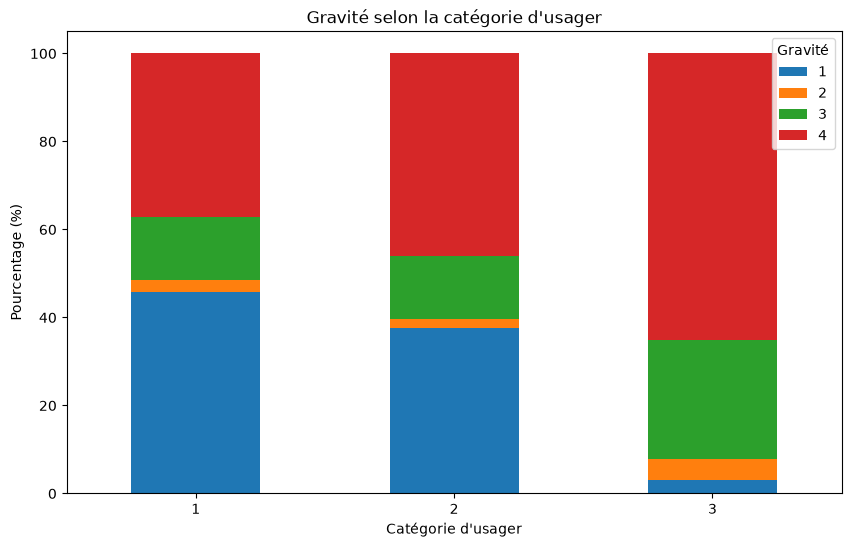

In [107]:
catu_grav.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title("Gravité selon la catégorie d'usager")
plt.xlabel("Catégorie d'usager")
plt.ylabel("Pourcentage (%)")
plt.legend(title="Gravité")
plt.xticks(rotation=0)
plt.show()

La répartition de `grav` varie selon la catégorie d’usager. Les piétons se distinguent particulièrement, avec 26,98 % de blessés hospitalisés et 4,72 % de personnes tuées, contre respectivement 14,34 % et 2,60 % chez les conducteurs. 
### grav x sexe

In [108]:
grav_sex = pd.crosstab(
    df['sexe'],
    df['grav'],
    normalize='index'
) * 100

grav_sex

grav,1,2,3,4
sexe,,,,
1.0,42.877918,3.062489,15.930651,38.128942
2.0,37.269416,1.833615,13.920255,46.976714


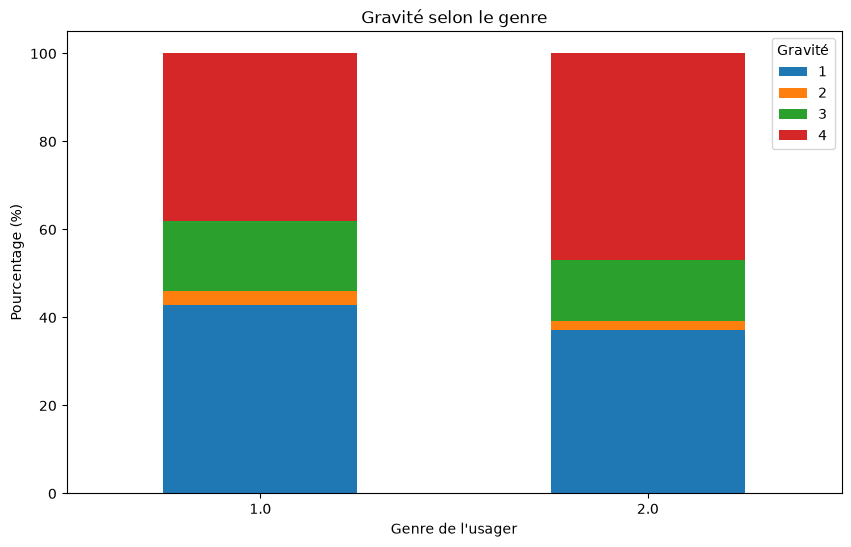

In [109]:
grav_sex.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title("Gravité selon le genre")
plt.xlabel("Genre de l'usager")
plt.ylabel("Pourcentage (%)")
plt.legend(title="Gravité")
plt.xticks(rotation=0)
plt.show()

La répartition de `grav` varie selon le sexe. La part de blessés légers (`grav = 4`) est plus élevée chez les femmes (46,98 %) que chez les hommes (38,13 %), tandis que la part de personnes tuées est plus élevée chez les hommes (3,06 % contre 1,83 %).
### grav x age_grp

In [110]:
grav_age = pd.crosstab(
    df['age_grp'],
    df['grav'],
    normalize='index'
)*100
grav_age

grav,1,2,3,4
age_grp,,,,
+65,39.788759,6.373255,21.852245,31.985740
-5,39.532240,1.380542,9.355205,49.732012
15-25,35.070648,2.210395,17.077476,45.641481
25-35,42.221952,1.986165,12.640151,43.151732
35-45,46.605545,2.123501,12.090449,39.180504
45-55,45.637108,2.417840,14.091231,37.853821
5-15,27.630571,0.959820,14.882320,56.527289
55-65,44.742986,3.119591,16.912209,35.225214


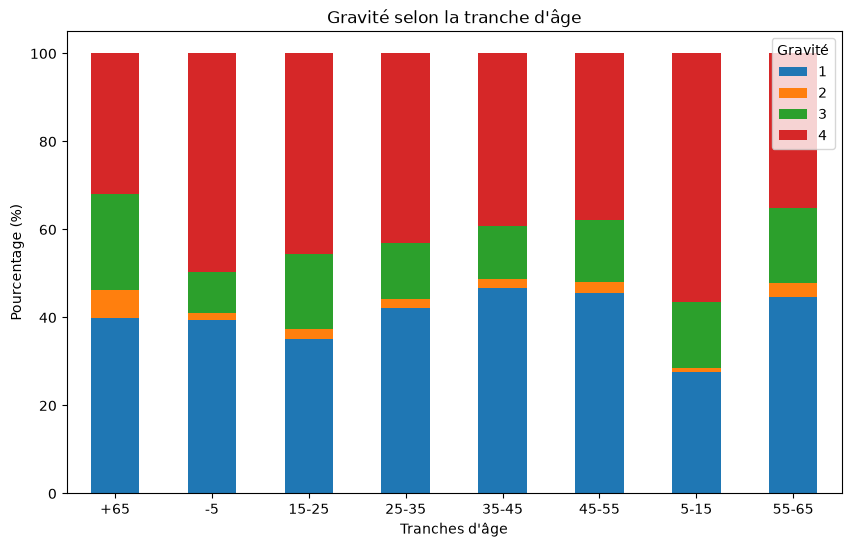

In [111]:
grav_age.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title("Gravité selon la tranche d'âge")
plt.xlabel("Tranches d'âge")
plt.ylabel("Pourcentage (%)")
plt.legend(title="Gravité")
plt.xticks(rotation=0)
plt.show()

La répartition de `grav` varie selon les tranches d’âge. Les `5-15` ans présentent la plus forte proportion de blessés légers (56,53 %), tandis que les `+65` ans présentent les proportions les plus élevées de blessés hospitalisés (21,85 %) et de personnes tuées (6,37 %).

### Grav x issecu

In [112]:
grav_secu = pd.crosstab(
    df['issecu'],
    df['grav'],
    normalize='index'
)*100
grav_secu

grav,1,2,3,4
issecu,,,,
False,22.148250,4.833713,21.210784,51.807253
True,46.050107,2.100293,13.731126,38.118474


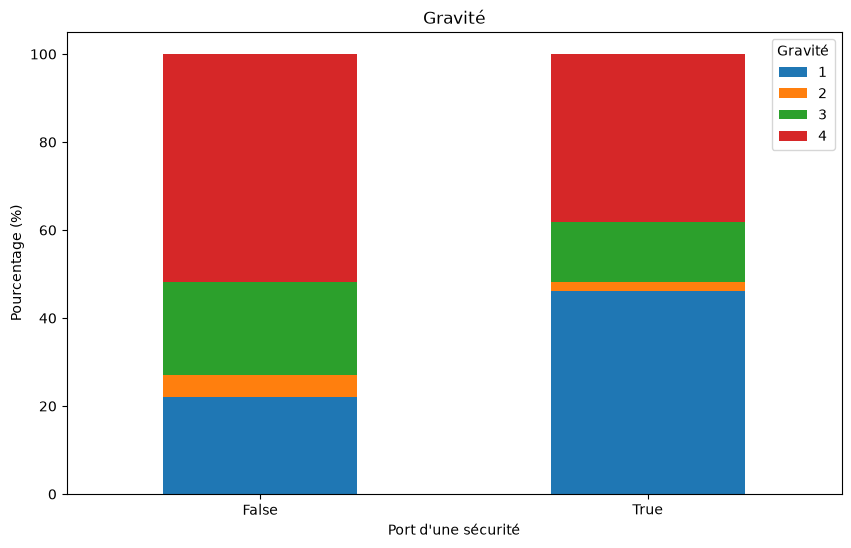

In [113]:
grav_secu.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title("Gravité")
plt.xlabel("Port d'une sécurité")
plt.ylabel("Pourcentage (%)")
plt.legend(title="Gravité")
plt.xticks(rotation=0)
plt.show()

La répartition de `grav` diffère selon le port d’un équipement de sécurité. Les usagers sans équipement (`False`) présentent davantage de blessures graves ou de décès : 21,21 % sont hospitalisés et 4,83 % sont tués, contre respectivement 13,73 % et 2,10 % chez les usagers avec équipement (`True`).
### 

In [114]:
grav_var = {}
for x in df[['catv_grp','lum','atm','surf','vma_grp','agg']]:
    grav_var[x] = pd.crosstab(
        df[x],
        df['grav'],
        normalize='index'
    )*100

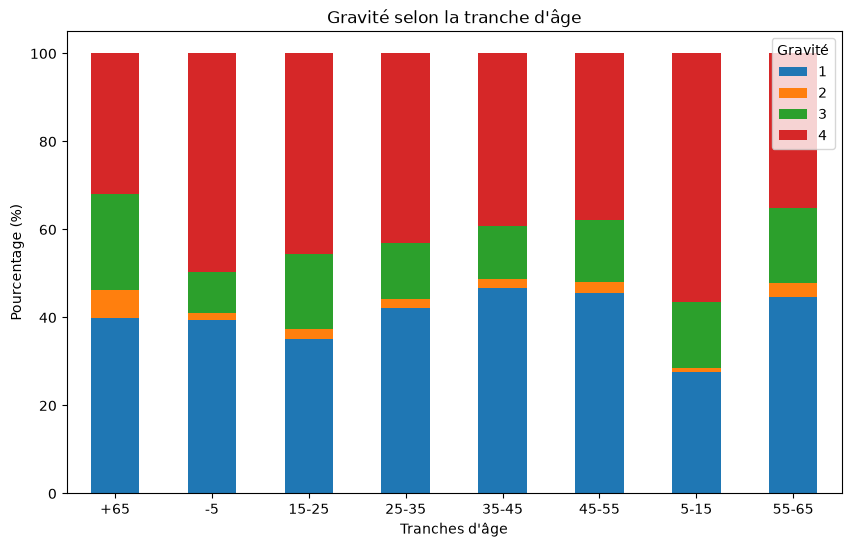

In [115]:
grav_age.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title("Gravité selon la tranche d'âge")
plt.xlabel("Tranches d'âge")
plt.ylabel("Pourcentage (%)")
plt.legend(title="Gravité")
plt.xticks(rotation=0)
plt.show()

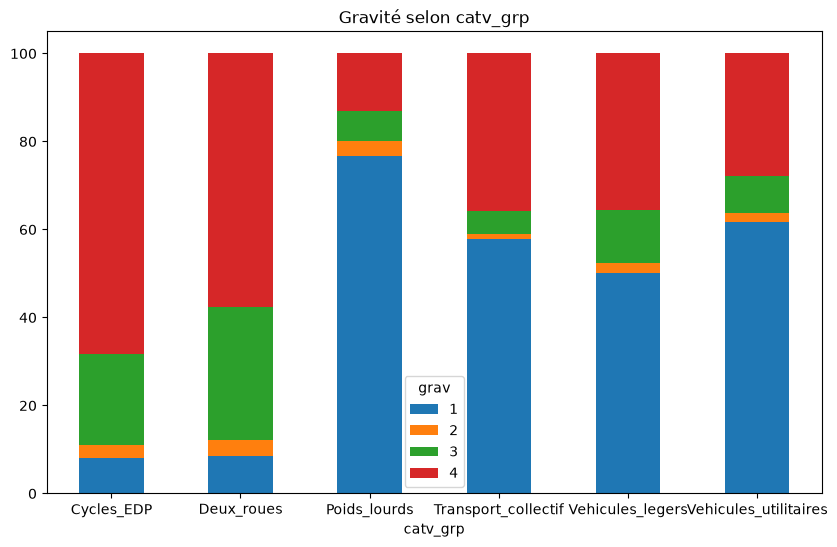

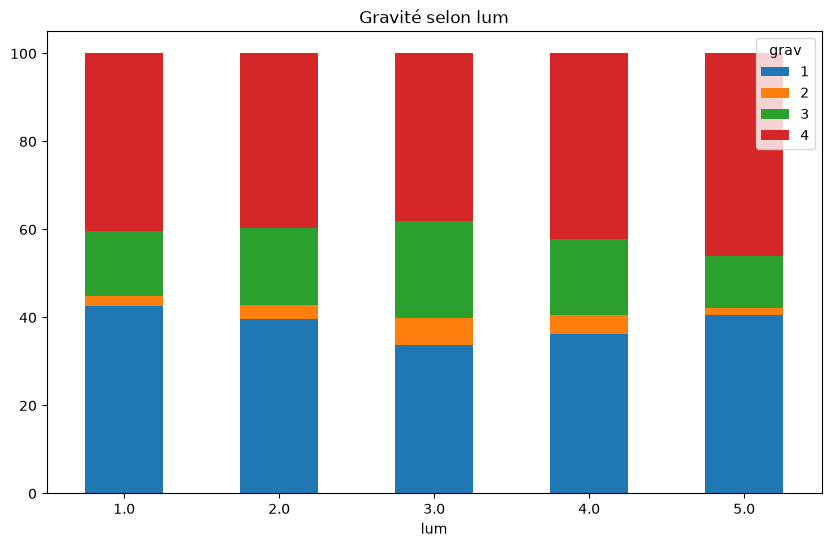

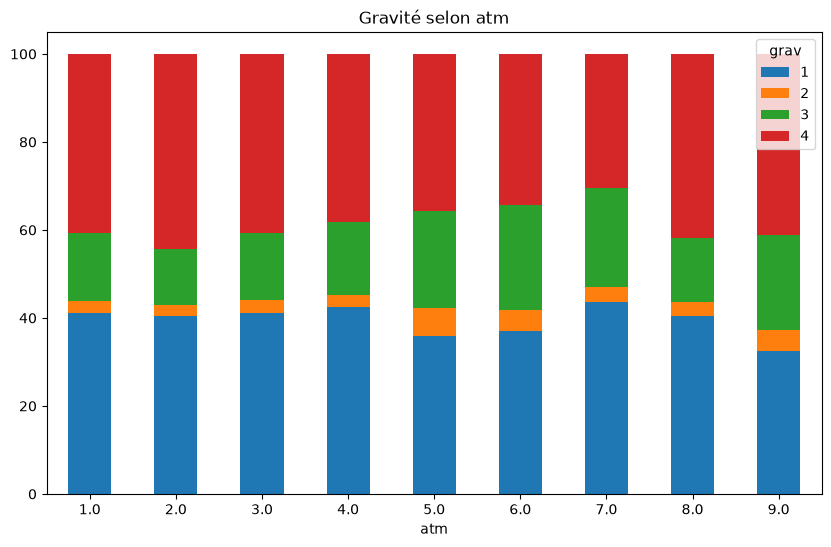

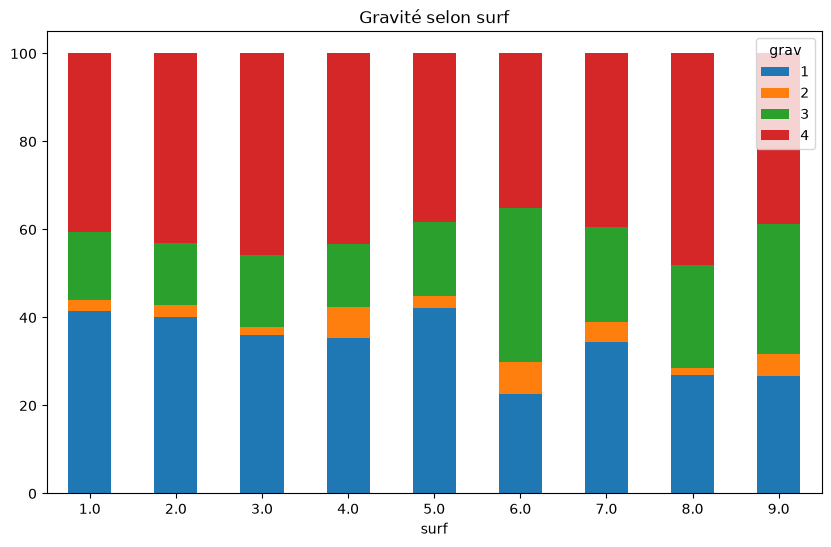

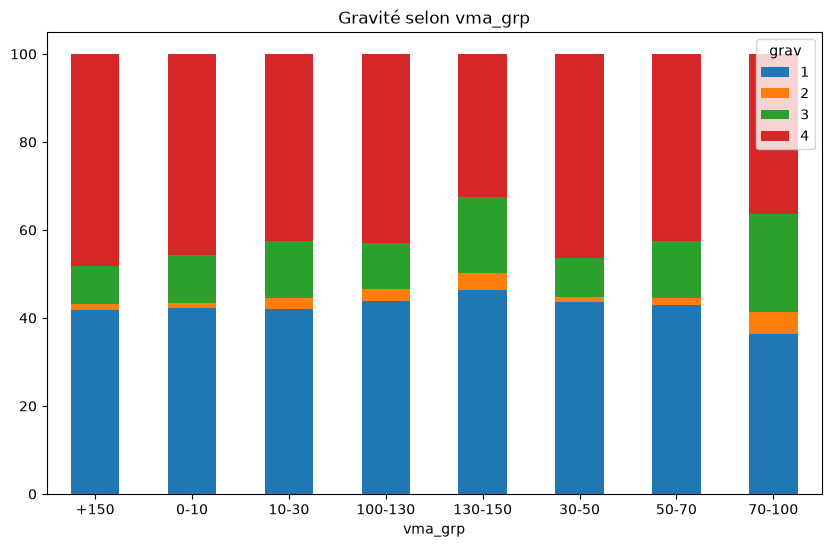

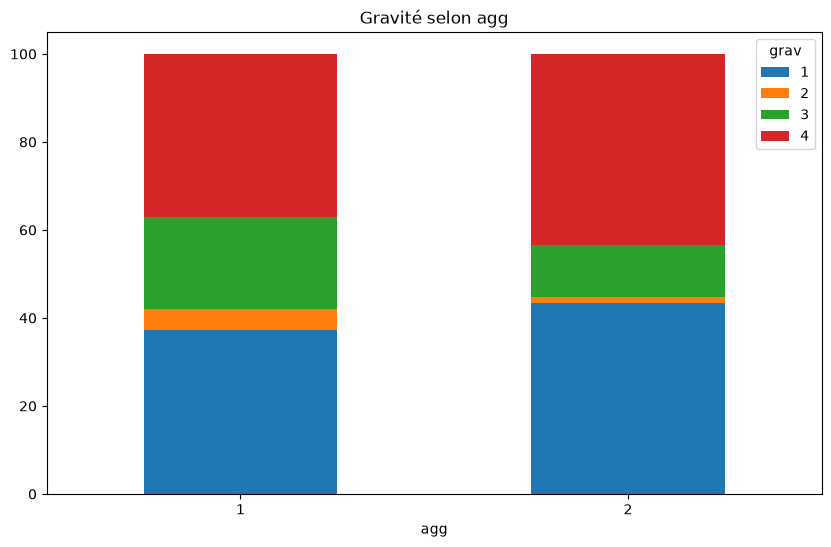

In [116]:
for x in grav_var:
    y = grav_var[x]

    y.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
    )

    plt.title(f'Gravité selon {x}')
    plt.xticks(rotation=0)
    plt.show()

In [117]:
grav_var

{'catv_grp': grav                           1         2          3          4
 catv_grp                                                        
 Cycles_EDP              8.072580  3.002640  20.552216  68.372563
 Deux_roues              8.447795  3.760907  30.177480  57.613818
 Poids_lourds           76.762782  3.368064   6.857281  13.011873
 Transport_collectif    57.812889  1.244091   5.051008  35.892013
 Vehicules_legers       50.084986  2.409389  11.885714  35.619911
 Vehicules_utilitaires  61.658016  2.145329   8.376586  27.820069,
 'lum': grav          1         2          3          4
 lum                                            
 1.0   42.565182  2.263231  14.770937  40.400650
 2.0   39.756074  3.053929  17.566562  39.623435
 3.0   33.659071  6.275251  21.946462  38.119216
 4.0   36.240187  4.413325  17.228941  42.117547
 5.0   40.526178  1.689222  11.861723  45.922877,
 'atm': grav          1         2          3          4
 atm                                            
 1.

**`catv_grp` × `grav`**  
La gravité varie fortement selon la catégorie de véhicule. Les `Deux_roues` présentent 30,18 % de blessés hospitalisés et 3,76 % de personnes tuées, contre 11,89 % et 2,41 % pour les `Vehicules_legers`. Les `Cycles_EDP` présentent également une forte proportion de blessés légers (68,37 %).

**`lum` × `grav`**  
La répartition varie selon les conditions d’éclairage. La modalité `3` présente les proportions les plus élevées de personnes tuées (6,28 %) et de blessés hospitalisés (21,95 %), tandis que la modalité `5` présente la plus forte proportion de blessés légers (45,92 %).

**`atm` × `grav`**  
Les différences entre les modalités restent globalement modérées. La modalité `5` se distingue toutefois avec 6,41 % de personnes tuées et 21,92 % de blessés hospitalisés.

**`surf` × `grav`**  
La répartition varie davantage pour certaines modalités minoritaires. La modalité `6` présente 7,36 % de personnes tuées et 35,06 % de blessés hospitalisés, tandis que la modalité `9` présente 29,50 % de blessés hospitalisés.

**`vma_grp` × `grav`**  
La répartition de la gravité varie selon les tranches de vitesse. La catégorie `70-100` présente les proportions les plus élevées de personnes tuées (4,90 %) et de blessés hospitalisés (22,30 %). Les autres catégories présentent des écarts plus modérés.

**`agg` × `grav`**  
La modalité `1` présente une proportion plus élevée de personnes tuées (4,66 %) et de blessés hospitalisés (21,06 %) que la modalité `2` (1,40 % et 11,62 %).

## Analyse mutlivarié
### grav x catu x isecu

In [118]:
multi_catu_secu = pd.crosstab(
    [df['catu'], df['issecu']],
    df['grav'],
    normalize='index'
) * 100

multi_catu_secu

grav                 1          2          3          4
catu issecu                                            
1    False   33.990080   4.769122  17.173169  44.067630
     True    47.814165   2.243375  13.869271  36.073190
2    False   28.754834   5.522042  21.268368  44.454756
     True    39.065022   1.495223  13.089158  46.350597
3    False    3.063804   4.677648  26.888142  65.370406
     True     9.012876  11.587983  41.630901  37.768240

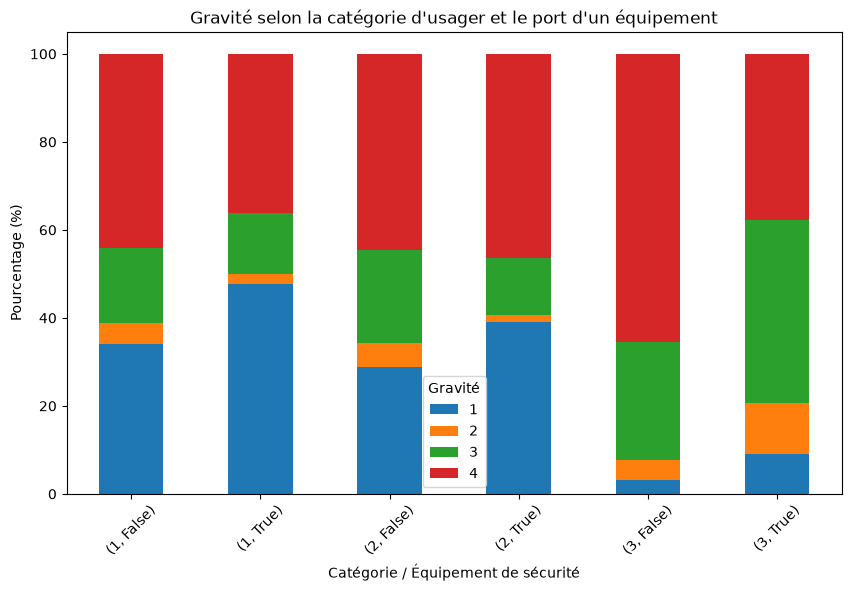

In [119]:
multi_catu_secu.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title("Gravité selon la catégorie d'usager et le port d'un équipement")
plt.xlabel("Catégorie / Équipement de sécurité")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=45)
plt.legend(title="Gravité")
plt.show()

La relation entre `issecu` et `grav` varie selon la catégorie d’usager. Chez les conducteurs et les passagers, le port d’un équipement est associé à une proportion plus faible de blessés hospitalisés et de personnes tuées. Chez les piétons, la répartition est différente : les usagers avec équipement présentent notamment 41,63 % de blessés hospitalisés et 11,59 % de personnes tuées.

### grav x age x catv

In [120]:
multi_age_catv = pd.crosstab(
    [df['age_grp'], df['catv_grp']],
    df['grav'],
    normalize='index'
) * 100

multi_age_catv

grav                                   1          2          3          4
age_grp catv_grp                                                         
+65     Cycles_EDP              2.207762  10.597258  37.392517  49.802463
        Deux_roues              7.003210   7.470090  38.838634  46.688065
        Poids_lourds           40.000000  22.000000  22.285714  15.714286
        Transport_collectif    22.937294   6.765677  13.036304  57.260726
        Vehicules_legers       46.819741   5.647849  19.137499  28.394912
        Vehicules_utilitaires  38.134150   7.116105  19.033027  35.716718
-5      Cycles_EDP             11.111111   0.925926  12.962963  75.000000
        Deux_roues              7.361963   0.000000  13.496933  79.141104
        Poids_lourds           40.000000   0.000000   0.000000  60.000000
        Transport_collectif    18.811881   0.990099   7.920792  72.277228
        Vehicules_legers       42.139175   1.362297   9.002209  47.496318
        Vehicules_utilitaires  36.666667   3.333333  12.083333  47.916667
15-25   Cycles_EDP             11.913707   1.236214  15.561750  71.288329
        Deux_roues              9.335449   2.686161  30.484718  57.493672
        Poids_lourds           72.125984   2.834646   7.401575  17.637795
        Transport_collectif    53.365004   0.475059   4.988124  41.171813
        Vehicules_legers       45.149963   2.216338  13.080709  39.552991
        Vehicules_utilitaires  57.817323   1.634284   9.224623  31.323770
25-35   Cycles_EDP             10.544413   1.246418  12.693410  75.515759
        Deux_roues              8.869048   3.214286  25.977183  61.939484
        Poids_lourds           80.357143   1.721939   4.209184  13.711735
        Transport_collectif    66.109785   0.636436   2.863962  30.389817
        Vehicules_legers       52.180801   1.790518   9.459214  36.569467
        Vehicules_utilitaires  66.723779   1.297271   6.400685  25.578265
35-45   Cycles_EDP              8.672421   1.808467  16.995479  72.523633
        Deux_roues              7.788925   4.258252  27.916060  60.036762
        Poids_lourds           78.143713   2.445110   6.237525  13.173653
        Transport_collectif    65.502495   0.641483   3.777619  30.078403
        Vehicules_legers       56.038244   1.701355   8.682128  33.578273
        Vehicules_utilitaires  67.984021   1.455272   5.835355  24.725353
45-55   Cycles_EDP              5.968839   2.391925  22.273425  69.365811
        Deux_roues              7.642800   4.567802  32.940020  54.849379
        Poids_lourds           79.800272   2.405810   6.128007  11.665910
        Transport_collectif    66.509434   1.010782   3.504043  28.975741
        Vehicules_legers       55.244173   1.922107   9.736656  33.097064
        Vehicules_utilitaires  65.898618   2.048131   6.878307  25.174945
5-15    Cycles_EDP              6.931090   1.442308  21.915064  69.711538
        Deux_roues              8.238124   1.082381  27.179796  63.499699
        Poids_lourds            8.000000   4.000000  40.000000  48.000000
        Transport_collectif    49.609375   0.390625   7.421875  42.578125
        Vehicules_legers       32.608853   0.902592  12.527980  53.960575
        Vehicules_utilitaires  25.826972   0.636132  14.503817  59.033079
55-65   Cycles_EDP              4.296974   4.805492  28.502415  62.395118
        Deux_roues              7.349858   5.771365  36.736959  50.141818
        Poids_lourds           78.551913   3.620219   7.172131  10.655738
        Transport_collectif    60.294118   1.470588   5.017301  33.217993
        Vehicules_legers       54.805043   2.330405  12.251645  30.612906
        Vehicules_utilitaires  64.972429   2.493407   8.631024  23.903141

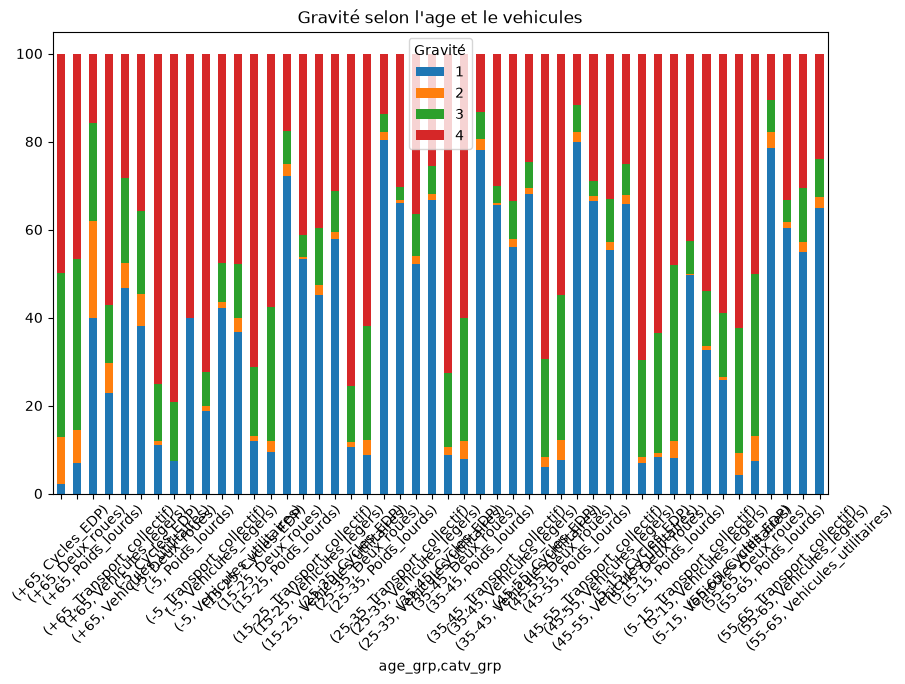

In [121]:
multi_age_catv.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title("Gravité selon l'age et le vehicules")
plt.xticks(rotation=45)
plt.legend(title="Gravité")
plt.show()

La gravité varie selon la combinaison de l’âge et de la catégorie de véhicule. Les `Deux_roues` présentent globalement davantage de blessés hospitalisés, notamment chez les `+65` (38,84 %) et les `55-65` (36,74 %). Les `Vehicules_legers` présentent une part plus élevée d’usagers indemnes, particulièrement chez les `25-35` (52,18 %) et les `35-45` (56,04 %).

## Relation entre variables
L’analyse des relations entre variables permet d’identifier les corrélations, les associations entre variables catégorielles et les éventuelles redondances.

Les variables age et vma sont étudiées à l’aide d’une matrice de corrélation. Pour les variables catégorielles, le V de Cramér permet de mesurer la force des associations entre elles.
### Matrice de corrélation 

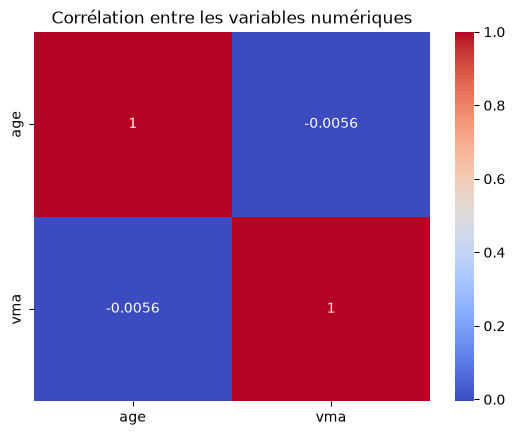

In [122]:
corr = df[['age', 'vma']].corr(method='spearman')

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Corrélation entre les variables numériques")
plt.show()

In [123]:
corr

,age,vma
age,1.000000,-0.005604
vma,-0.005604,1.000000


La corrélation entre `age` et `vma` est de -0,0056, ce qui indique une relation linéaire quasi nulle entre les deux variables. Elles apportent donc des informations largement indépendantes.
### Associations catégorielles

In [124]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    phi2 = chi2 / n

    r, k = table.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))

In [125]:
cat_vars = [
    'catu',
    'sexe',
    'lum',
    'agg',
    'atm',
    'surf',
    'catv_grp',
    'issecu',
    'age_grp',
    'vma_grp'
]

In [126]:
assoc = pd.DataFrame(
    index=cat_vars,
    columns=cat_vars,
    dtype=float
)

for x in cat_vars:
    for y in cat_vars:
        assoc.loc[x, y] = cramers_v(df[x], df[y])

assoc

,catu,sexe,lum,agg,atm,surf,catv_grp,issecu,age_grp,vma_grp
catu,1.000000,0.222238,0.078232,0.220286,0.034475,0.022521,0.153837,0.553391,0.296050,0.178597
sexe,0.222238,0.999995,0.056141,0.004706,0.023281,0.017059,0.239937,0.036049,0.079237,0.014610
lum,0.078232,0.056141,1.000000,0.377192,0.101124,0.090926,0.067783,0.044034,0.093157,0.186971
agg,0.220286,0.004706,0.377192,0.999996,0.076406,0.063909,0.201864,0.174791,0.022796,0.852010
atm,0.034475,0.023281,0.101124,0.076406,1.000000,0.393966,0.037322,0.024912,0.022163,0.036249
surf,0.022521,0.017059,0.090926,0.063909,0.393966,1.000000,0.039601,0.014839,0.012915,0.026649
catv_grp,0.153837,0.239937,0.067783,0.201864,0.037322,0.039601,1.000000,0.323618,0.088853,0.121418
issecu,0.553391,0.036049,0.044034,0.174791,0.024912,0.014839,0.323618,0.999994,0.133543,0.211563
age_grp,0.296050,0.079237,0.093157,0.022796,0.022163,0.012915,0.088853,0.133543,1.000000,0.023642
vma_grp,0.178597,0.014610,0.186971,0.852010,0.036249,0.026649,0.121418,0.211563,0.023642,1.000000


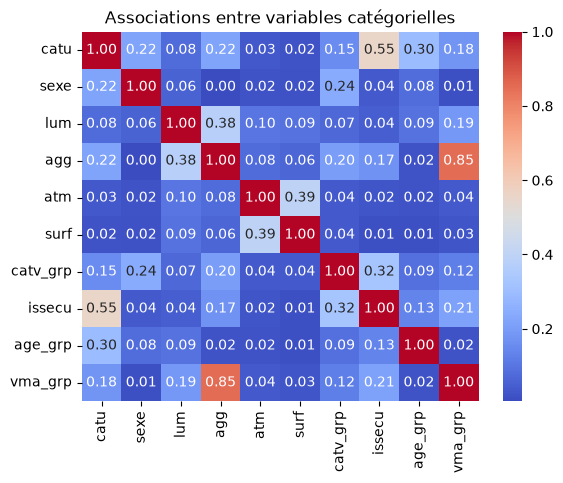

In [127]:
sns.heatmap(
    assoc,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title("Associations entre variables catégorielles")
plt.show()

In [128]:
df.info()

<class 'pandas.DataFrame'>
Index: 479684 entries, 0 to 506885
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   grav      479684 non-null  int64  
 1   catu      479684 non-null  int64  
 2   sexe      479684 non-null  float64
 3   an        479684 non-null  int64  
 4   lum       479684 non-null  float64
 5   agg       479684 non-null  int64  
 6   atm       479684 non-null  float64
 7   surf      479684 non-null  float64
 8   vma       479684 non-null  float64
 9   catv_grp  479684 non-null  str    
 10  issecu    479684 non-null  bool   
 11  age       479684 non-null  float64
 12  age_grp   479684 non-null  str    
 13  vma_grp   479684 non-null  str    
dtypes: bool(1), float64(6), int64(4), str(3)
memory usage: 51.7 MB


In [129]:
df = df.drop(columns=['age','vma','an'])

## Définition de la variable cible

Pour la modélisation, `grav` est transformée en variable binaire :

- **0 : gravité non grave** → `1` et `4`
- **1 : gravité grave** → `2` et `3`

Cette transformation permet de passer d'une classification à 4 classes à une **classification binaire**, plus adaptée à l'objectif de prédiction de la gravité d'un accident.

In [130]:
df['grav'] = df['grav'].map({
    1: 0,
    4: 0,
    2: 1,
    3: 1
})

In [131]:
df.info()

<class 'pandas.DataFrame'>
Index: 479684 entries, 0 to 506885
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   grav      479684 non-null  int64  
 1   catu      479684 non-null  int64  
 2   sexe      479684 non-null  float64
 3   lum       479684 non-null  float64
 4   agg       479684 non-null  int64  
 5   atm       479684 non-null  float64
 6   surf      479684 non-null  float64
 7   catv_grp  479684 non-null  str    
 8   issecu    479684 non-null  bool   
 9   age_grp   479684 non-null  str    
 10  vma_grp   479684 non-null  str    
dtypes: bool(1), float64(4), int64(3), str(3)
memory usage: 40.7 MB


In [132]:
df['grav'].value_counts(normalize=True)*100

grav
0    82.045055
1    17.954945
Name: proportion, dtype: float64

L’analyse du V de Cramér met en évidence plusieurs associations entre les variables. La plus forte concerne `agg` et `vma_grp` avec une valeur de 0,85. Cette association peut s’expliquer par le lien entre le statut d’agglomération et les limitations de vitesse applicables sur le réseau routier. Les deux variables restent toutefois distinctes sur le plan conceptuel. Une association importante est également observée entre `catu` et `issecu` (0,55).

Des associations modérées apparaissent entre `atm` et `surf` (0,39), ainsi qu’entre `catv_grp` et `issecu` (0,32). La relation entre `catu` et `age_grp` est plus faible (0,30).

Ces résultats permettent d’identifier les variables potentiellement redondantes avant la modélisation.
# EDA - Conclusion
L’analyse exploratoire montre une répartition déséquilibrée de la variable cible `grav`, avec environ 41 % d’usagers indemnes, 41 % de blessés légers, 15,29 % de blessés hospitalisés et 2,67 % de personnes tuées.

Les analyses bivariées mettent en évidence des différences de répartition de la gravité selon la catégorie d’usager (`catu`), la catégorie de véhicule (`catv_grp`), l’âge (`age_grp`) et le port d’un équipement de sécurité (`issecu`).

L’analyse des relations entre variables révèle notamment une forte association entre `agg` et `vma_grp` (V de Cramér = 0,85). Des associations plus modérées sont également observées entre `catu` et `issecu`, ainsi qu’entre `atm` et `surf`.

In [133]:
# df.to_csv("../data/processed/baac_final.csv", index=False)